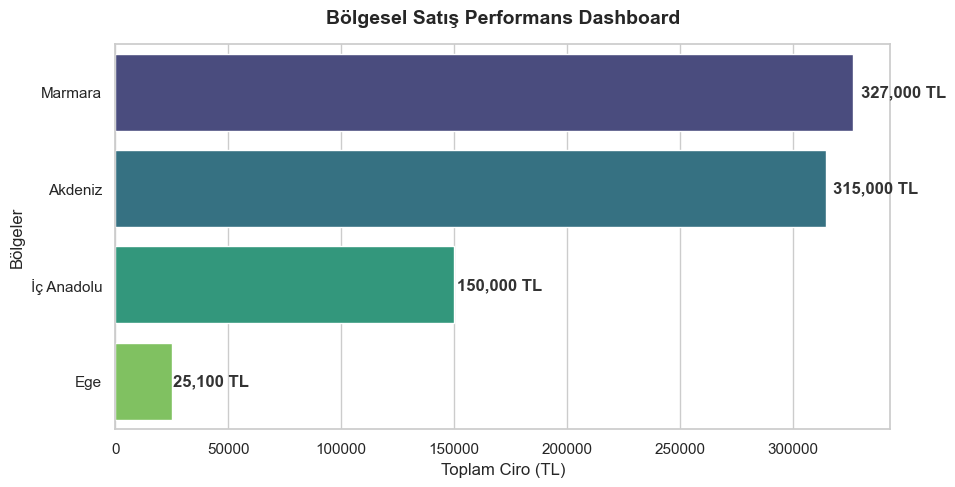

--------------------------------------------------
📊 STRATEJİK RAPOR ÖZETİ | 03.04.2026
--------------------------------------------------
✅ Toplam Ciro: 817,100.00 TL
✅ En Çok Satış Yapılan Kategori: Gıda
--------------------------------------------------
 DİKKAT: Performansı düşük bölgeler: İç Anadolu, Ege
 ÖNERİ: Bu bölgelerde kampanya bütçesi %10 artırılmalıdır.
--------------------------------------------------


,Tarih,Bolge,Urun_Kategorisi,Satis_Adedi,Birim_Fiyat,Toplam_Ciro
0,2026-01-10,Marmara,Teknoloji,15,18000,270000
1,2026-01-25,Ege,Gıda,50,250,12500
2,2026-02-05,İç Anadolu,Teknoloji,10,15000,150000
3,2026-02-28,Marmara,Mobilya,6,9500,57000
4,2026-03-12,Ege,Gıda,42,300,12600


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# 1. JUPYTER AYARI: Grafikleri hücre içinde göster
%matplotlib inline

# --- ADIM 1: ANALİZ İÇİN VERİ SETİ OLUŞTURMA ---
# (Dışarıdan dosya okumak yerine direkt bellek üzerinde (In-Memory) oluşturalım ki hata vermesin)
data = {
    'Tarih': ['2026-01-10', '2026-01-25', '2026-02-05', '2026-02-28', '2026-03-12', '2026-03-30'],
    'Bolge': ['Marmara', 'Ege', 'İç Anadolu', 'Marmara', 'Ege', 'Akdeniz'],
    'Urun_Kategorisi': ['Teknoloji', 'Gıda', 'Teknoloji', 'Mobilya', 'Gıda', 'Teknoloji'],
    'Satis_Adedi': [15, 50, 10, 6, 42, 18],
    'Birim_Fiyat': [18000, 250, 15000, 9500, 300, 17500]
}

df = pd.DataFrame(data)
df['Tarih'] = pd.to_datetime(df['Tarih'])
df['Toplam_Ciro'] = df['Satis_Adedi'] * df['Birim_Fiyat']

# --- ADIM 2: STRATEJİK ANALİZ VE HESAPLAMALAR ---
# Bölge bazlı ciro
bolge_ciro = df.groupby('Bolge')['Toplam_Ciro'].sum().sort_values(ascending=False)

# Ortalama altı bölgeler (Risk Tespiti)
esik_deger = bolge_ciro.mean()
zayif_bolgeler = bolge_ciro[bolge_ciro < esik_deger].index.tolist()

# En çok satan kategori
lider_kategori = df.groupby('Urun_Kategorisi')['Satis_Adedi'].sum().idxmax()

# --- ADIM 3: GÖRSELLEŞTİRME (DASHBOARD) ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# Güncel Seaborn standartlarında çizim
ax = sns.barplot(
    x=bolge_ciro.values, 
    y=bolge_ciro.index, 
    hue=bolge_ciro.index, 
    palette="viridis", 
    legend=False
)

# Barların üzerine şık rakam etiketleri ekleme
for i, v in enumerate(bolge_ciro.values):
    ax.text(v + (v * 0.01), i, f"{v:,.0f} TL", va='center', fontweight='bold', color='#333')

plt.title('Bölgesel Satış Performans Dashboard', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Toplam Ciro (TL)')
plt.ylabel('Bölgeler')
plt.show() # Grafiği Jupyter'de anında gösterir

# --- ADIM 4: YÖNETİCİ ÖZETİ (INTERAKTİF ÇIKTI) ---
print("-" * 50)
print(f"📊 STRATEJİK RAPOR ÖZETİ | {datetime.now().strftime('%d.%m.%Y')}")
print("-" * 50)
print(f"✅ Toplam Ciro: {df['Toplam_Ciro'].sum():,.2f} TL")
print(f"✅ En Çok Satış Yapılan Kategori: {lider_kategori}")
print("-" * 50)

if zayif_bolgeler:
    print(f" DİKKAT: Performansı düşük bölgeler: {', '.join(zayif_bolgeler)}")
    print(" ÖNERİ: Bu bölgelerde kampanya bütçesi %10 artırılmalıdır.")
else:
    print(" Tüm bölgeler hedef beklentilerin üzerindedir.")
print("-" * 50)

# Verinin son halini tabloda görelim (Jupyter'in tablo özelliğini kullanır)
df.head()